# Attribute Presence via Semantic Similarity

Semantic similarity (cosine distance) between the reviews and the attribute (keywords and part from groundtruth reviews containing the attribute)




In [ ]:
from sentence_transformers import SentenceTransformer, util
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, recall_score, confusion_matrix
import numpy as np
import seaborn as sns

### Model choice: sentence-transformers/all-mpnet-base-v2

- Embedding dimension: 764 (can understand nuances)
- Max input tokens: 384 (more than enough for the reviews)
- Very fast (even on a small laptop)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2", cache_folder='../../embedding_models').to(device)

In [ ]:
from langdetect import detect, DetectorFactory, LangDetectException

# Ensure consistent language detection results
DetectorFactory.seed = 0

def safe_detect(text):
    if not isinstance(text, str):
        return "unknown"
    
    # FIX: If text is very short, just assume English (or your main language)
    if len(text) < 15:
        return "en"
        
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

def clean_data(df, review_col):

    df[review_col] = df[review_col].fillna("").astype(str)

    df['ID'] = df.index.astype(int)
    df['ID'] += 1  # Start IDs from 1 instead of 0

    df['lang'] = df[review_col].apply(safe_detect)

    return df

### Load data

In [ ]:
df_5 = pd.read_excel('../../data/initial_data/Study 5 reviews.xlsx')
df_5 = clean_data(df_5, "Review")

df_5.columns

reviews = df_5["Review"].fillna("").tolist() 
reviews[:5]

['Very bad', 'horrible', 'Had a bad time here', 'Crowded paths', 'Horrible']

### Reviews and Groundtruth embedding

For the groundtruth, I tried with only the name of the attributes, with description of the attributes or with relevant part of reviews/keywords.
The last approach is the one that works best.

NOTE: keywords and sample from reviews after the first 100, and then validation on the first 100, so no leakage

In [ ]:
attribute_names = [
    'Cleanliness_and_maintenance',
    'Waiting_and_queuing_times',
    'Quality_of_exhibits',
    'Quantity_of_exhibits',
    'Helfpulness_of_staff'
]

reviews_example = [
    "hot, air conditioning and ventilation not working, dirty, escalator not working",
    'huge crowd, this is overwhelming wiht long queues, hope it is was less busy',
    'No guide, interactive, clear detailed description and information, nice visit, educational for kids, learning, well-organized',
    'different exhibits, a lot plenty to see, many things',
    'cashier, unfriendly, helpful staff'
]

review_embeddings = model.encode(reviews, convert_to_tensor=True, show_progress_bar=True)
attr_embeddings = model.encode(reviews_example, convert_to_tensor=True)

Batches: 100%|██████████| 23/23 [00:00<00:00, 97.18it/s]


### Evaluation on the first 100 reviews

We use the AUC to evaluate the method and the groundtruth choice

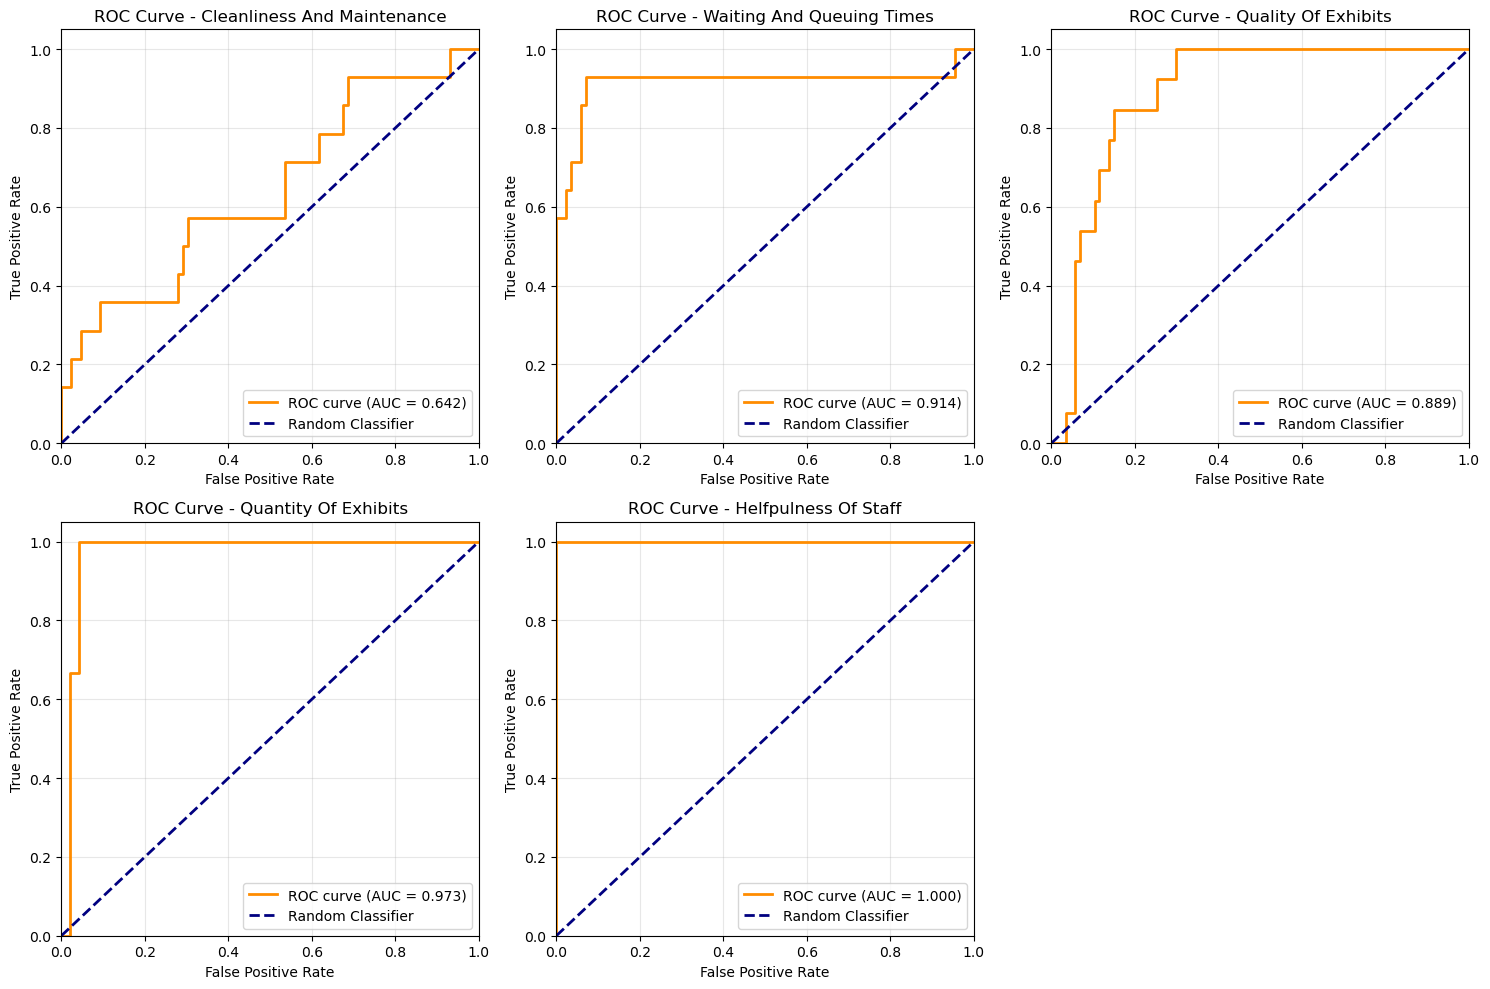


AUC Scores for Each Attribute:
Cleanliness And Maintenance              AUC = 0.6420
Waiting And Queuing Times                AUC = 0.9145
Quality Of Exhibits                      AUC = 0.8886
Quantity Of Exhibits                     AUC = 0.9725
Helfpulness Of Staff                     AUC = 1.0000


In [ ]:
valid_df = pd.read_csv('../data/labeled_presence/label_Study_5_reviews.csv')
valid_df = valid_df.iloc[:100,:] # Validation on the last 100 (hand-labeled)

valid_review_embeddings = model.encode(
    valid_df["Review"].fillna("").tolist(), 
    convert_to_tensor=True
)
valid_cosine_scores = util.cos_sim(valid_review_embeddings, attr_embeddings)
valid_scores = valid_cosine_scores.cpu().numpy()

# Plot ROC curves
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, attr_name in enumerate(attribute_names):
    y_true = valid_df[attr_name].astype(int).values
    y_scores = valid_scores[:, i]
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    axes[i].plot(fpr, tpr, color='darkorange', lw=2, 
                 label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
                 label='Random Classifier')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'ROC Curve - {attr_name.replace("_", " ").title()}')
    axes[i].legend(loc="lower right")
    axes[i].grid(True, alpha=0.3)

# Remove the extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('roc_curves_all_attributes.png', dpi=300, bbox_inches='tight')
plt.show()

# Print AUC scores
print("\n" + "="*60)
print("AUC Scores for Each Attribute:")
print("="*60)
for i, attr_name in enumerate(attribute_names):
    y_true = valid_df[attr_name].astype(int).values
    y_scores = valid_scores[:, i]
    roc_auc = roc_auc_score(y_true, y_scores)
    print(f"{attr_name.replace('_', ' ').title():<40} AUC = {roc_auc:.4f}")

### Get the optimal selection threshold

In [ ]:
print("\n" + "="*60)
print("Optimal Thresholds (Youden's J statistic):")
print("="*60)

optimal_thresholds = []

for i, attr_name in enumerate(attribute_names):
    y_true = valid_df[attr_name].astype(int).values
    y_scores = valid_scores[:, i]
    
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    
    # Youden's J statistic: maximize (TPR - FPR)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]

    optimal_thresholds.append(optimal_threshold)
    
    print(f"{attr_name.replace('_', ' ').title():<40} Threshold = {optimal_threshold:.4f}")


Optimal Thresholds (Youden's J statistic):
Cleanliness And Maintenance              Threshold = 0.2199
Waiting And Queuing Times                Threshold = 0.3116
Quality Of Exhibits                      Threshold = 0.2020
Quantity Of Exhibits                     Threshold = 0.5533
Helfpulness Of Staff                     Threshold = 0.6707


In [ ]:
cosine_scores = util.cos_sim(review_embeddings, attr_embeddings)
cosine_scores_np = cosine_scores.cpu().numpy()

predictions = np.zeros_like(cosine_scores_np, dtype=int)
# Use the optimal thresolds obtained above
for i, threshold in enumerate(optimal_thresholds):
    predictions[:, i] = (cosine_scores_np[:, i] > threshold).astype(int)

for i, attr_name in enumerate(attribute_names):
    col_name = f"pred_{attr_name.replace(' ', '_')}"
    df_1[col_name] = predictions[:, i]

df_1.head()

,ID,Review,Satisfaction_final,Cleanliness_and_maintenance,Waiting_and_queuing_times,Quality_of_exhibits,Quantity_of_exhibits,Helfpulness_of_staff,Cleanliness_and_maintenance_sentiment,Waiting_and_queuing_times_sentiment,...,Quantity_of_exhibits_sentiment,Helfpulness_of_staff_sentiment,Unnamed: 13,Emotional_intensity_LLM,lang,pred_Cleanliness_and_maintenance,pred_Waiting_and_queuing_times,pred_Quality_of_exhibits,pred_Quantity_of_exhibits,pred_Helfpulness_of_staff
0,1,Very bad,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,en,0,0,0,0,0
1,2,horrible,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,en,0,0,0,0,0
2,3,Had a bad time here,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,en,0,0,0,0,0
3,4,Crowded paths,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,en,0,1,0,0,0
4,5,Horrible,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,en,0,0,0,0,0


Percentage reviews well classified for all attributes:
 - Overall: 0.5500

Accuracy Scores per Attribute:
 - Cleanliness_and_maintenance: 0.6800
 - Waiting_and_queuing_times: 0.9300
 - Quality_of_exhibits: 0.7400
 - Quantity_of_exhibits: 0.9500
 - Helfpulness_of_staff: 1.0000
Recall Scores per Attribute:
 - Cleanliness_and_maintenance: 0.5714
 - Waiting_and_queuing_times: 0.9286
 - Quality_of_exhibits: 1.0000
 - Quantity_of_exhibits: 0.6667
 - Helfpulness_of_staff: 1.0000


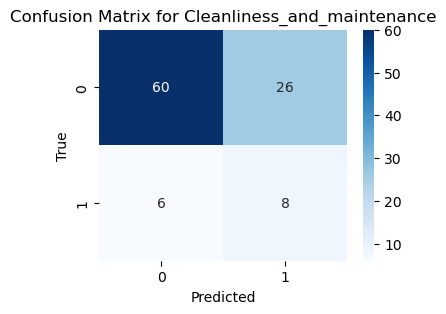

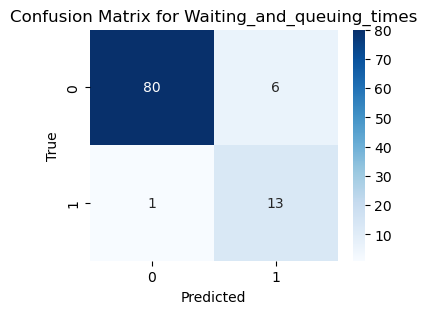

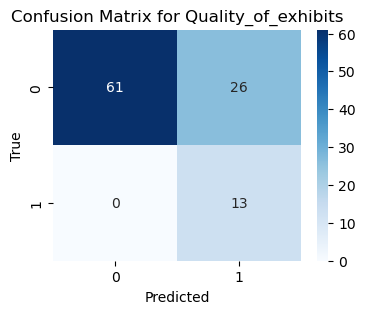

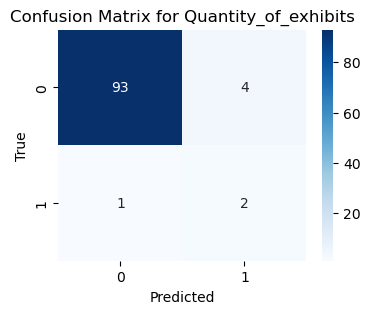

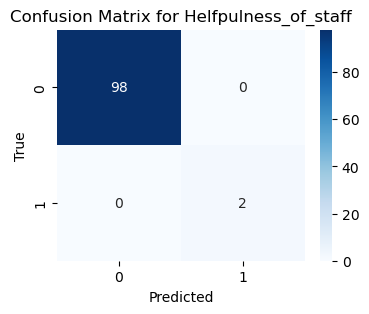

In [ ]:
predicted_column_names = [f"pred_{attr.replace(' ', '_')}" for attr in attribute_names]
pred_df =  df_1.iloc[:100,:]

accuracy_scores = {}
recall_scores = {}
for attr_name in attribute_names:
    y_true = valid_df[attr_name].astype(int).tolist()
    y_pred = pred_df[f"pred_{attr_name}"].astype(int).tolist()[:len(y_true)]
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    accuracy_scores[attr_name] = accuracy
    recall_scores[attr_name] = recall

print("Percentage reviews well classified for all attributes:")
well_classified = (pred_df[predicted_column_names].astype(int).values == valid_df[attribute_names].astype(int).values).all(axis=1).mean()
print(f" - Overall: {well_classified:.4f}\n")

print("Accuracy Scores per Attribute:")
for attr_name, score in accuracy_scores.items():
    print(f" - {attr_name}: {score:.4f}")

print("Recall Scores per Attribute:")
for attr_name, score in recall_scores.items():
    print(f" - {attr_name}: {score:.4f}")

# create a confusion matrix for each attribute
for attr_name in attribute_names:
    y_true = valid_df[attr_name].astype(int).tolist()
    y_pred = pred_df[f"pred_{attr_name}"].astype(int).tolist()[:len(y_true)]
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
    plt.title(f'Confusion Matrix for {attr_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
